# EXPLORACIÓN INICIAL DEL DATASET MOVIELENS

## IMPORTACIÓN DE LIBRERÍAS

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Definición de rutas y carga de datos

In [26]:
DATA_DIR = Path("../data/raw/ml-latest-small")

ratings_path = DATA_DIR / "ratings.csv"
movies_path = DATA_DIR / "movies.csv"
tags_path = DATA_DIR / "tags.csv"
links_path = DATA_DIR / "links.csv"

In [27]:
ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path)
tags = pd.read_csv(tags_path)
links = pd.read_csv(links_path)

## Comprobación de la carga del dataset

In [28]:
print("Ratings:", ratings.shape)
print("Movies:", movies.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

ratings.head()

Ratings: (100836, 4)
Movies: (9742, 3)
Tags: (3683, 4)
Links: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Información general y tipos de datos

In [29]:
ratings.info()
print()
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


## Estadísticos descriptivos

In [30]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


## Número de usuarios y películas

In [31]:
print("Usuarios:", ratings["userId"].nunique())
print("Películas valoradas:", ratings["movieId"].nunique())
print("Valoración mínima:", ratings["rating"].min())
print("Valoración máxima:", ratings["rating"].max())

Usuarios: 610
Películas valoradas: 9724
Valoración mínima: 0.5
Valoración máxima: 5.0


## Distribución de las valoraciones

In [32]:
ratings["rating"].value_counts().sort_index()

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

In [33]:
(ratings["rating"]
 .value_counts(normalize=True)
 .sort_index() * 100)

rating
0.5     1.358642
1.0     2.787695
1.5     1.776151
2.0     7.488397
2.5     5.503987
3.0    19.880797
3.5    13.027093
4.0    26.595660
4.5     8.480106
5.0    13.101472
Name: proportion, dtype: float64

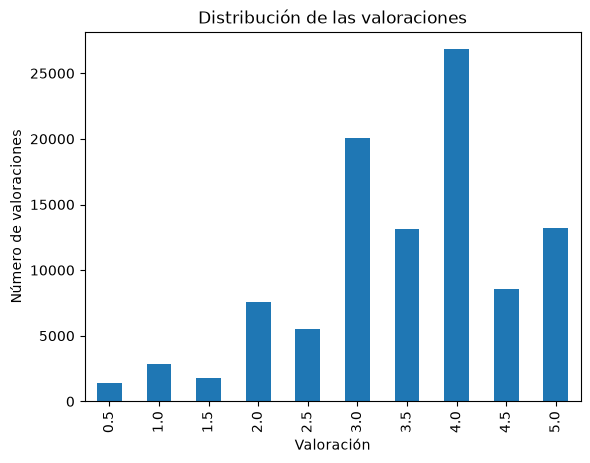

In [34]:
ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución de las valoraciones")
plt.xlabel("Valoración")
plt.ylabel("Número de valoraciones")

plt.show()

## Actividad de los usuarios

In [35]:
ratings_por_usuario = ratings.groupby("userId")["rating"].count()

ratings_por_usuario.head()

userId
1    232
2     29
3     39
4    216
5     44
Name: rating, dtype: int64

In [36]:
ratings_por_usuario.describe()

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64

In [37]:
# Usuario con más valoraciones
usuario_mas_activo = ratings_por_usuario.idxmax()
max_valoraciones = ratings_por_usuario.max()

# Usuario con menos valoraciones
usuario_menos_activo = ratings_por_usuario.idxmin()
min_valoraciones = ratings_por_usuario.min()

print(f"Usuario más activo: {usuario_mas_activo}")
print(f"Número de valoraciones: {max_valoraciones}\n")

print(f"Usuario menos activo: {usuario_menos_activo}")
print(f"Número de valoraciones: {min_valoraciones}")

Usuario más activo: 414
Número de valoraciones: 2698

Usuario menos activo: 53
Número de valoraciones: 20


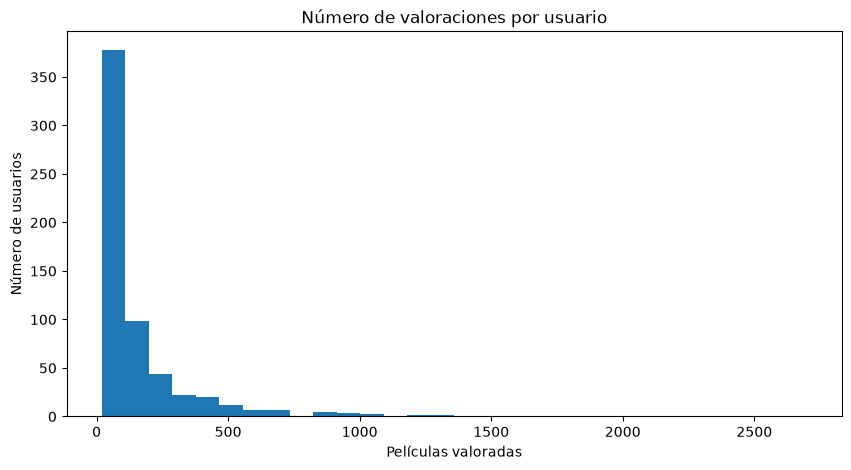

In [38]:
plt.figure(figsize=(10,5))

plt.hist(ratings_por_usuario, bins=30)

plt.title("Número de valoraciones por usuario")
plt.xlabel("Películas valoradas")
plt.ylabel("Número de usuarios")

plt.show()

## Actividad de las películas

In [43]:
ratings_por_pelicula = ratings.groupby("movieId")["rating"].count()

ratings_por_pelicula.head()

movieId
1    215
2    110
3     52
4      7
5     49
Name: rating, dtype: int64

In [44]:
ratings_por_pelicula.describe()

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64

In [45]:
pelicula_mas_valorada = ratings_por_pelicula.idxmax()
max_valoraciones = ratings_por_pelicula.max()

pelicula_menos_valorada = ratings_por_pelicula.idxmin()
min_valoraciones = ratings_por_pelicula.min()

print(f"Película más valorada (movieId): {pelicula_mas_valorada}")
print(f"Número de valoraciones: {max_valoraciones}\n")

print(f"Película menos valorada (movieId): {pelicula_menos_valorada}")
print(f"Número de valoraciones: {min_valoraciones}")

Película más valorada (movieId): 356
Número de valoraciones: 329

Película menos valorada (movieId): 49
Número de valoraciones: 1


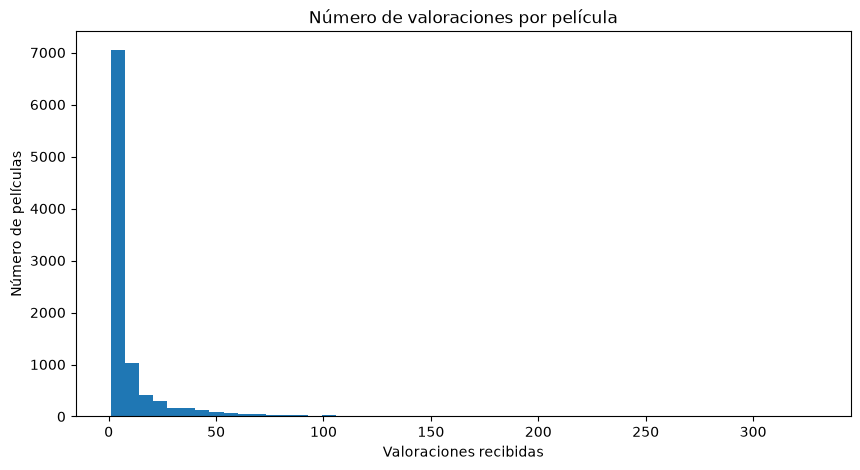

In [46]:
plt.figure(figsize=(10,5))

plt.hist(ratings_por_pelicula, bins=50)

plt.title("Número de valoraciones por película")
plt.xlabel("Valoraciones recibidas")
plt.ylabel("Número de películas")

plt.show()

## Construcción de la matriz usuario-pelicula

In [47]:
matriz_usuario_pelicula = ratings.pivot(
    index="userId",
    columns="movieId",
    values="rating"
)

matriz_usuario_pelicula

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Densidad de la matriz usuario-pelicula

In [48]:
num_usuarios = matriz_usuario_pelicula.shape[0]
num_peliculas = matriz_usuario_pelicula.shape[1]

valoraciones_posibles = num_usuarios * num_peliculas
valoraciones_reales = ratings.shape[0]

densidad = valoraciones_reales / valoraciones_posibles

print(f"Usuarios: {num_usuarios}")
print(f"Películas: {num_peliculas}")
print(f"Valoraciones posibles: {valoraciones_posibles:,}")
print(f"Valoraciones reales: {valoraciones_reales:,}")
print(f"Densidad de la matriz: {densidad:.2%}")

Usuarios: 610
Películas: 9724
Valoraciones posibles: 5,931,640
Valoraciones reales: 100,836
Densidad de la matriz: 1.70%
